In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix


Імпорт данних

In [3]:
df = pd.read_csv('abalone/abalone.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Перша строчка не назва стовбців, перейменуємо їх

In [4]:
df.columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 
              'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Перевірка на пусті данні

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


Пропусків немає, з категоральних фічей тільки перший  стовпець зі статтю, заміню позначення літерами на числа де:
* 0 ― M
* 1 ― F
* 2 ― I


In [6]:
df.loc[df['Sex'] == 'M', 'Sex'] = 0
df.loc[df['Sex'] == 'F', 'Sex'] = 1
df.loc[df['Sex'] == 'I', 'Sex'] = 2
df['Sex'] = df['Sex'].astype(int)
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


З даними тепер все добре, тому можемо перейти до аналізу через корреляцію

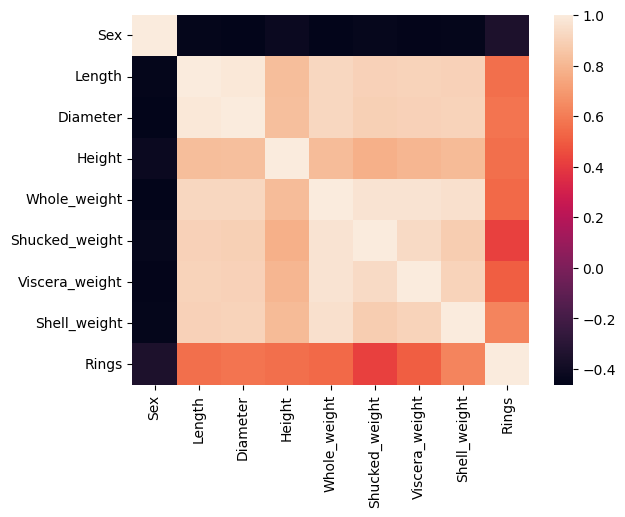

In [7]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix);

Бачимо корреляцію з усіма параметрами досить непогана, думаю можна спробувати додати фічу пов'язану з співвідношенням тіла до ваги

Sex                  -0.351822
Length                0.556720
Diameter              0.574660
Height                0.557467
Whole_weight          0.540390
Shucked_weight        0.420884
Viscera_weight        0.503819
Shell_weight          0.627574
Rings                 1.000000
ratio_size_to_meat    0.338376
Water_weight          0.499294
size                  0.544952
Name: Rings, dtype: float64


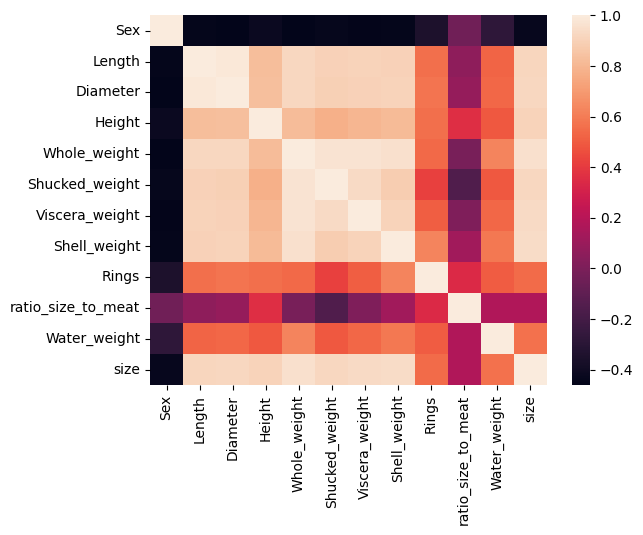

In [8]:
df['ratio_size_to_meat'] = df['Length'] * df['Diameter'] * df['Height'] / df['Shucked_weight']
df['Water_weight'] = df['Whole_weight'] - (df['Shucked_weight'] + df['Viscera_weight'] + df['Shell_weight'])
df['size'] = df['Length'] * df['Diameter'] * df['Height']
corr_matrix = df.corr()
sns.heatmap(corr_matrix);
print(df.corr()['Rings'])

Нові фічі непогано корелююця, size має меньшу корреляцію, в порівнянні зі звичайними параметрами розміру, але на хітмапі їх корреляція між собою велика, тому size можна залишити, а length, diametr та height видалити

In [9]:
df.drop(['Length', 'Diameter', 'Height'], axis=1, inplace=True)

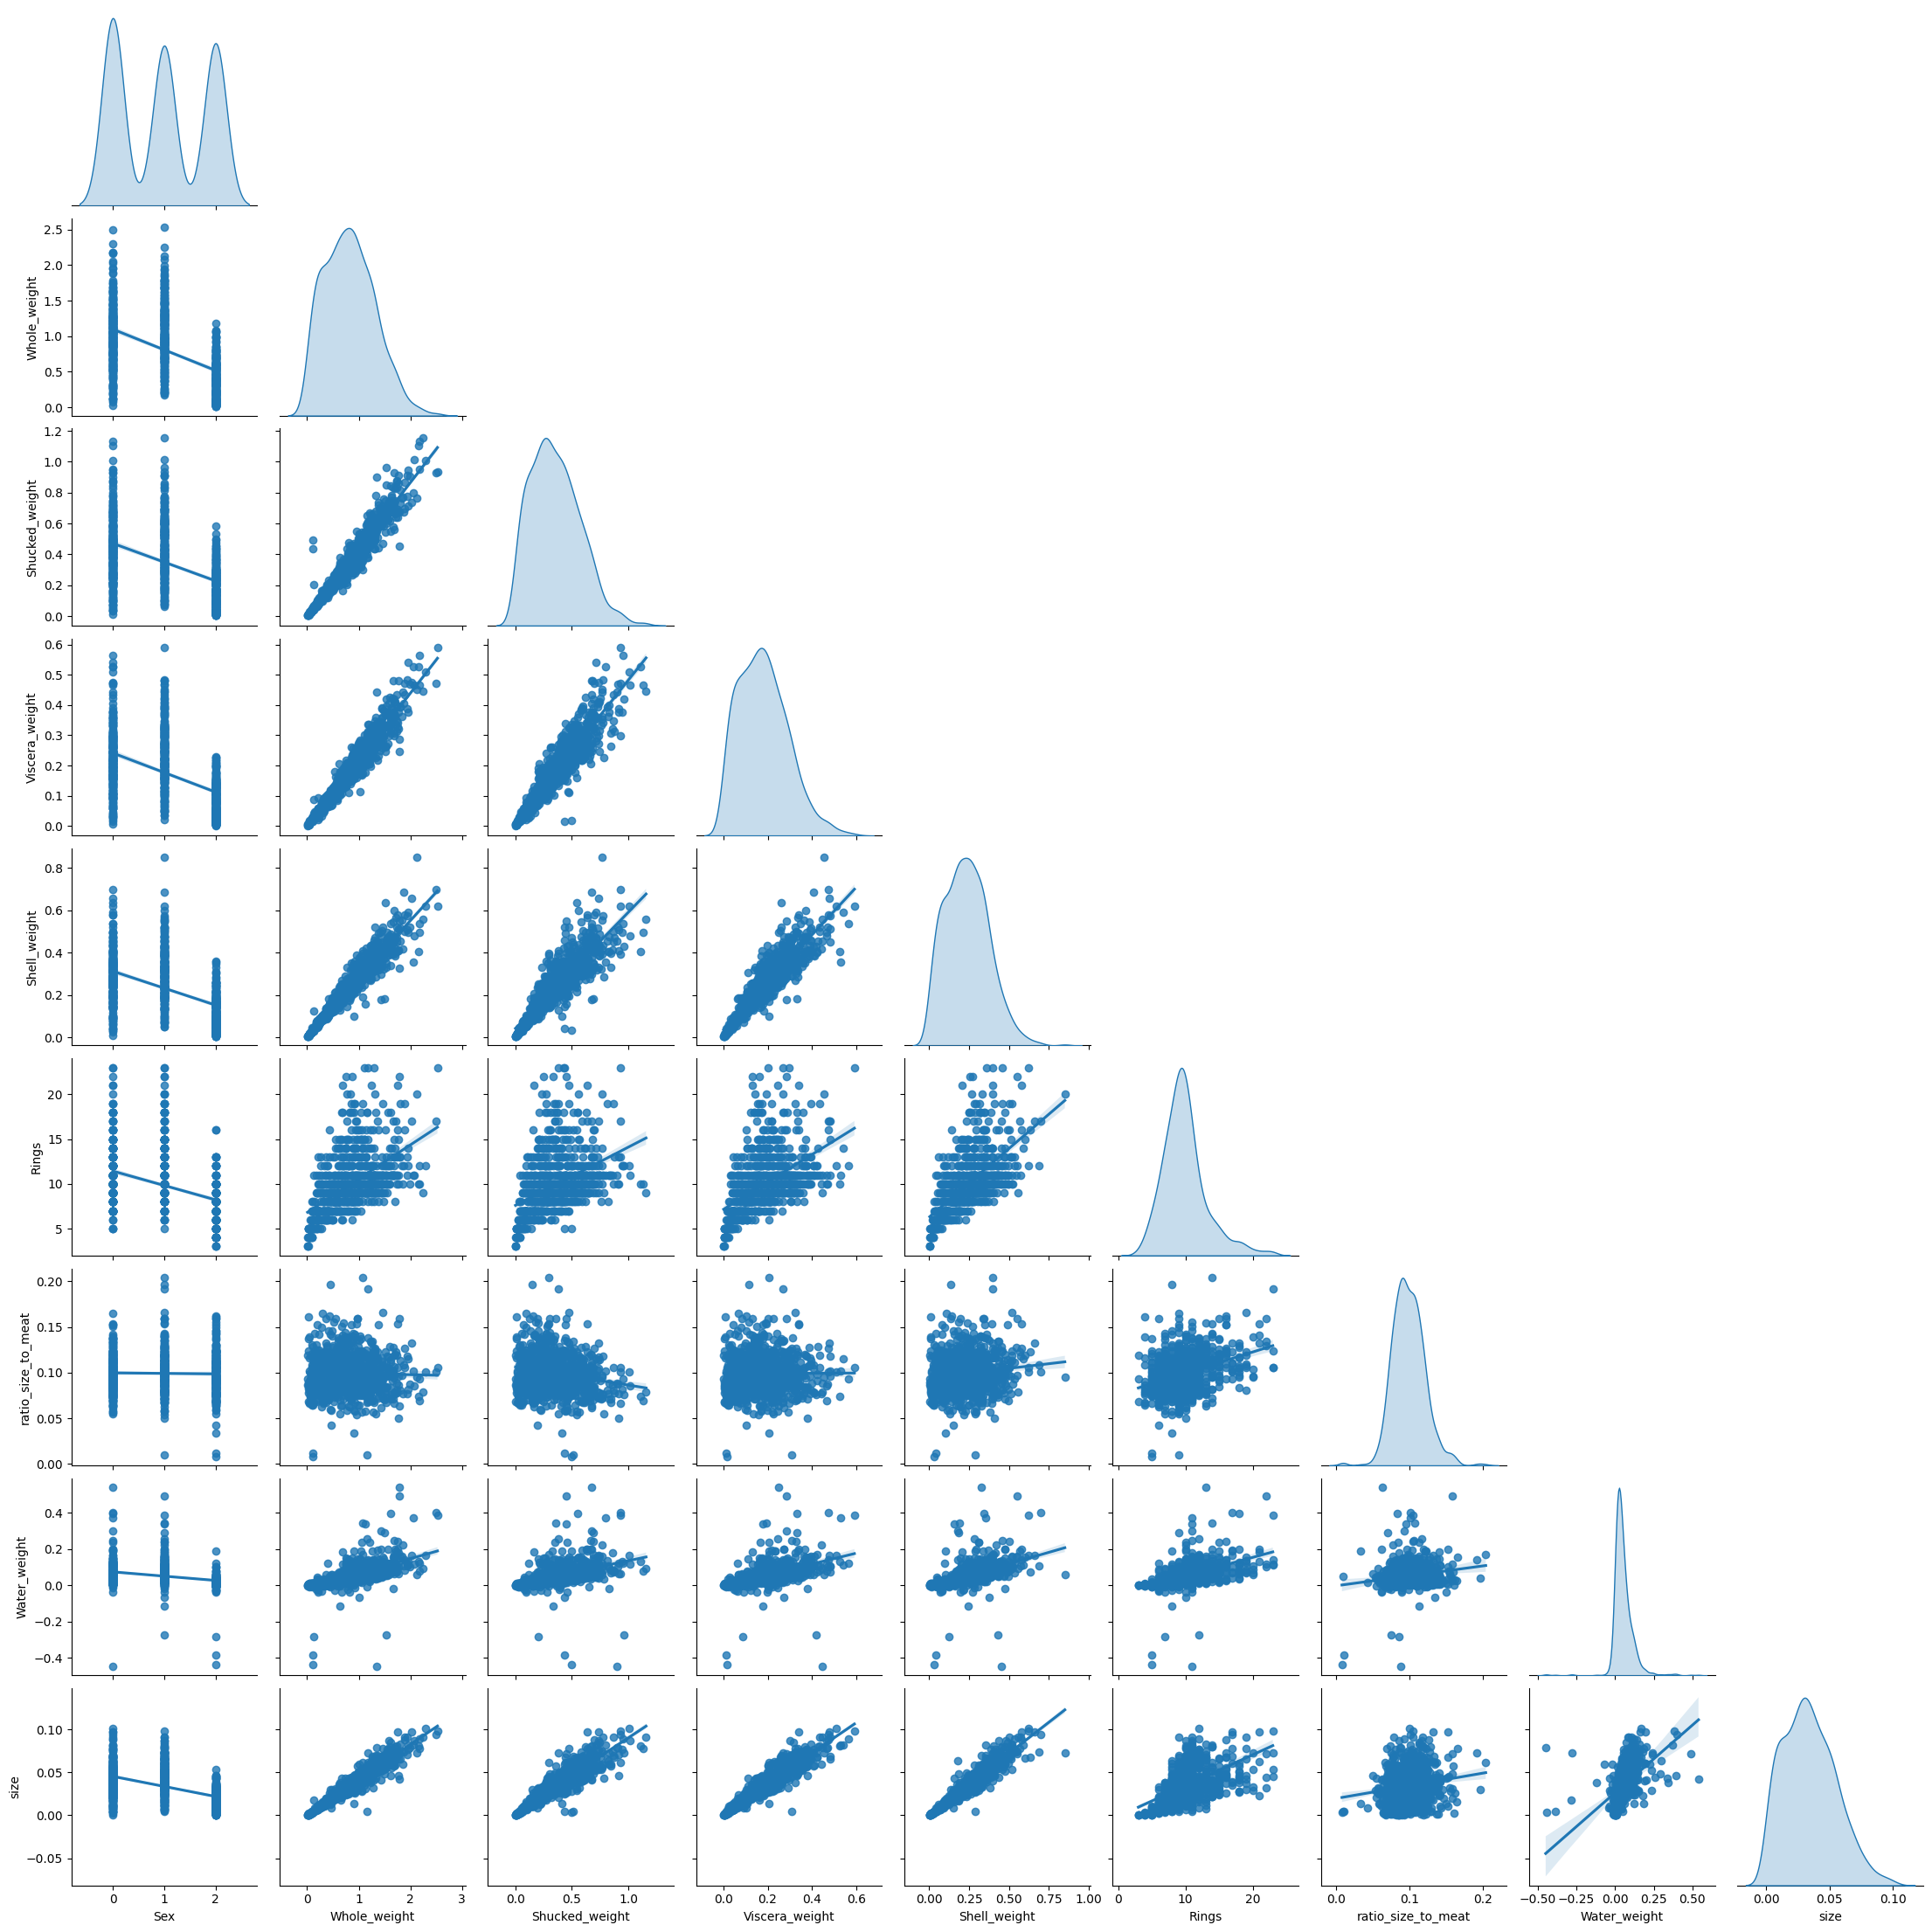

In [10]:
sns.pairplot(df.sample(frac=0.2, random_state=42), corner=True, kind='reg', diag_kind='kde')

Water_weight має майже горизонтальну лінію з rings, тому видалю її

In [11]:
df.drop(['Water_weight'], axis=1, inplace=True)

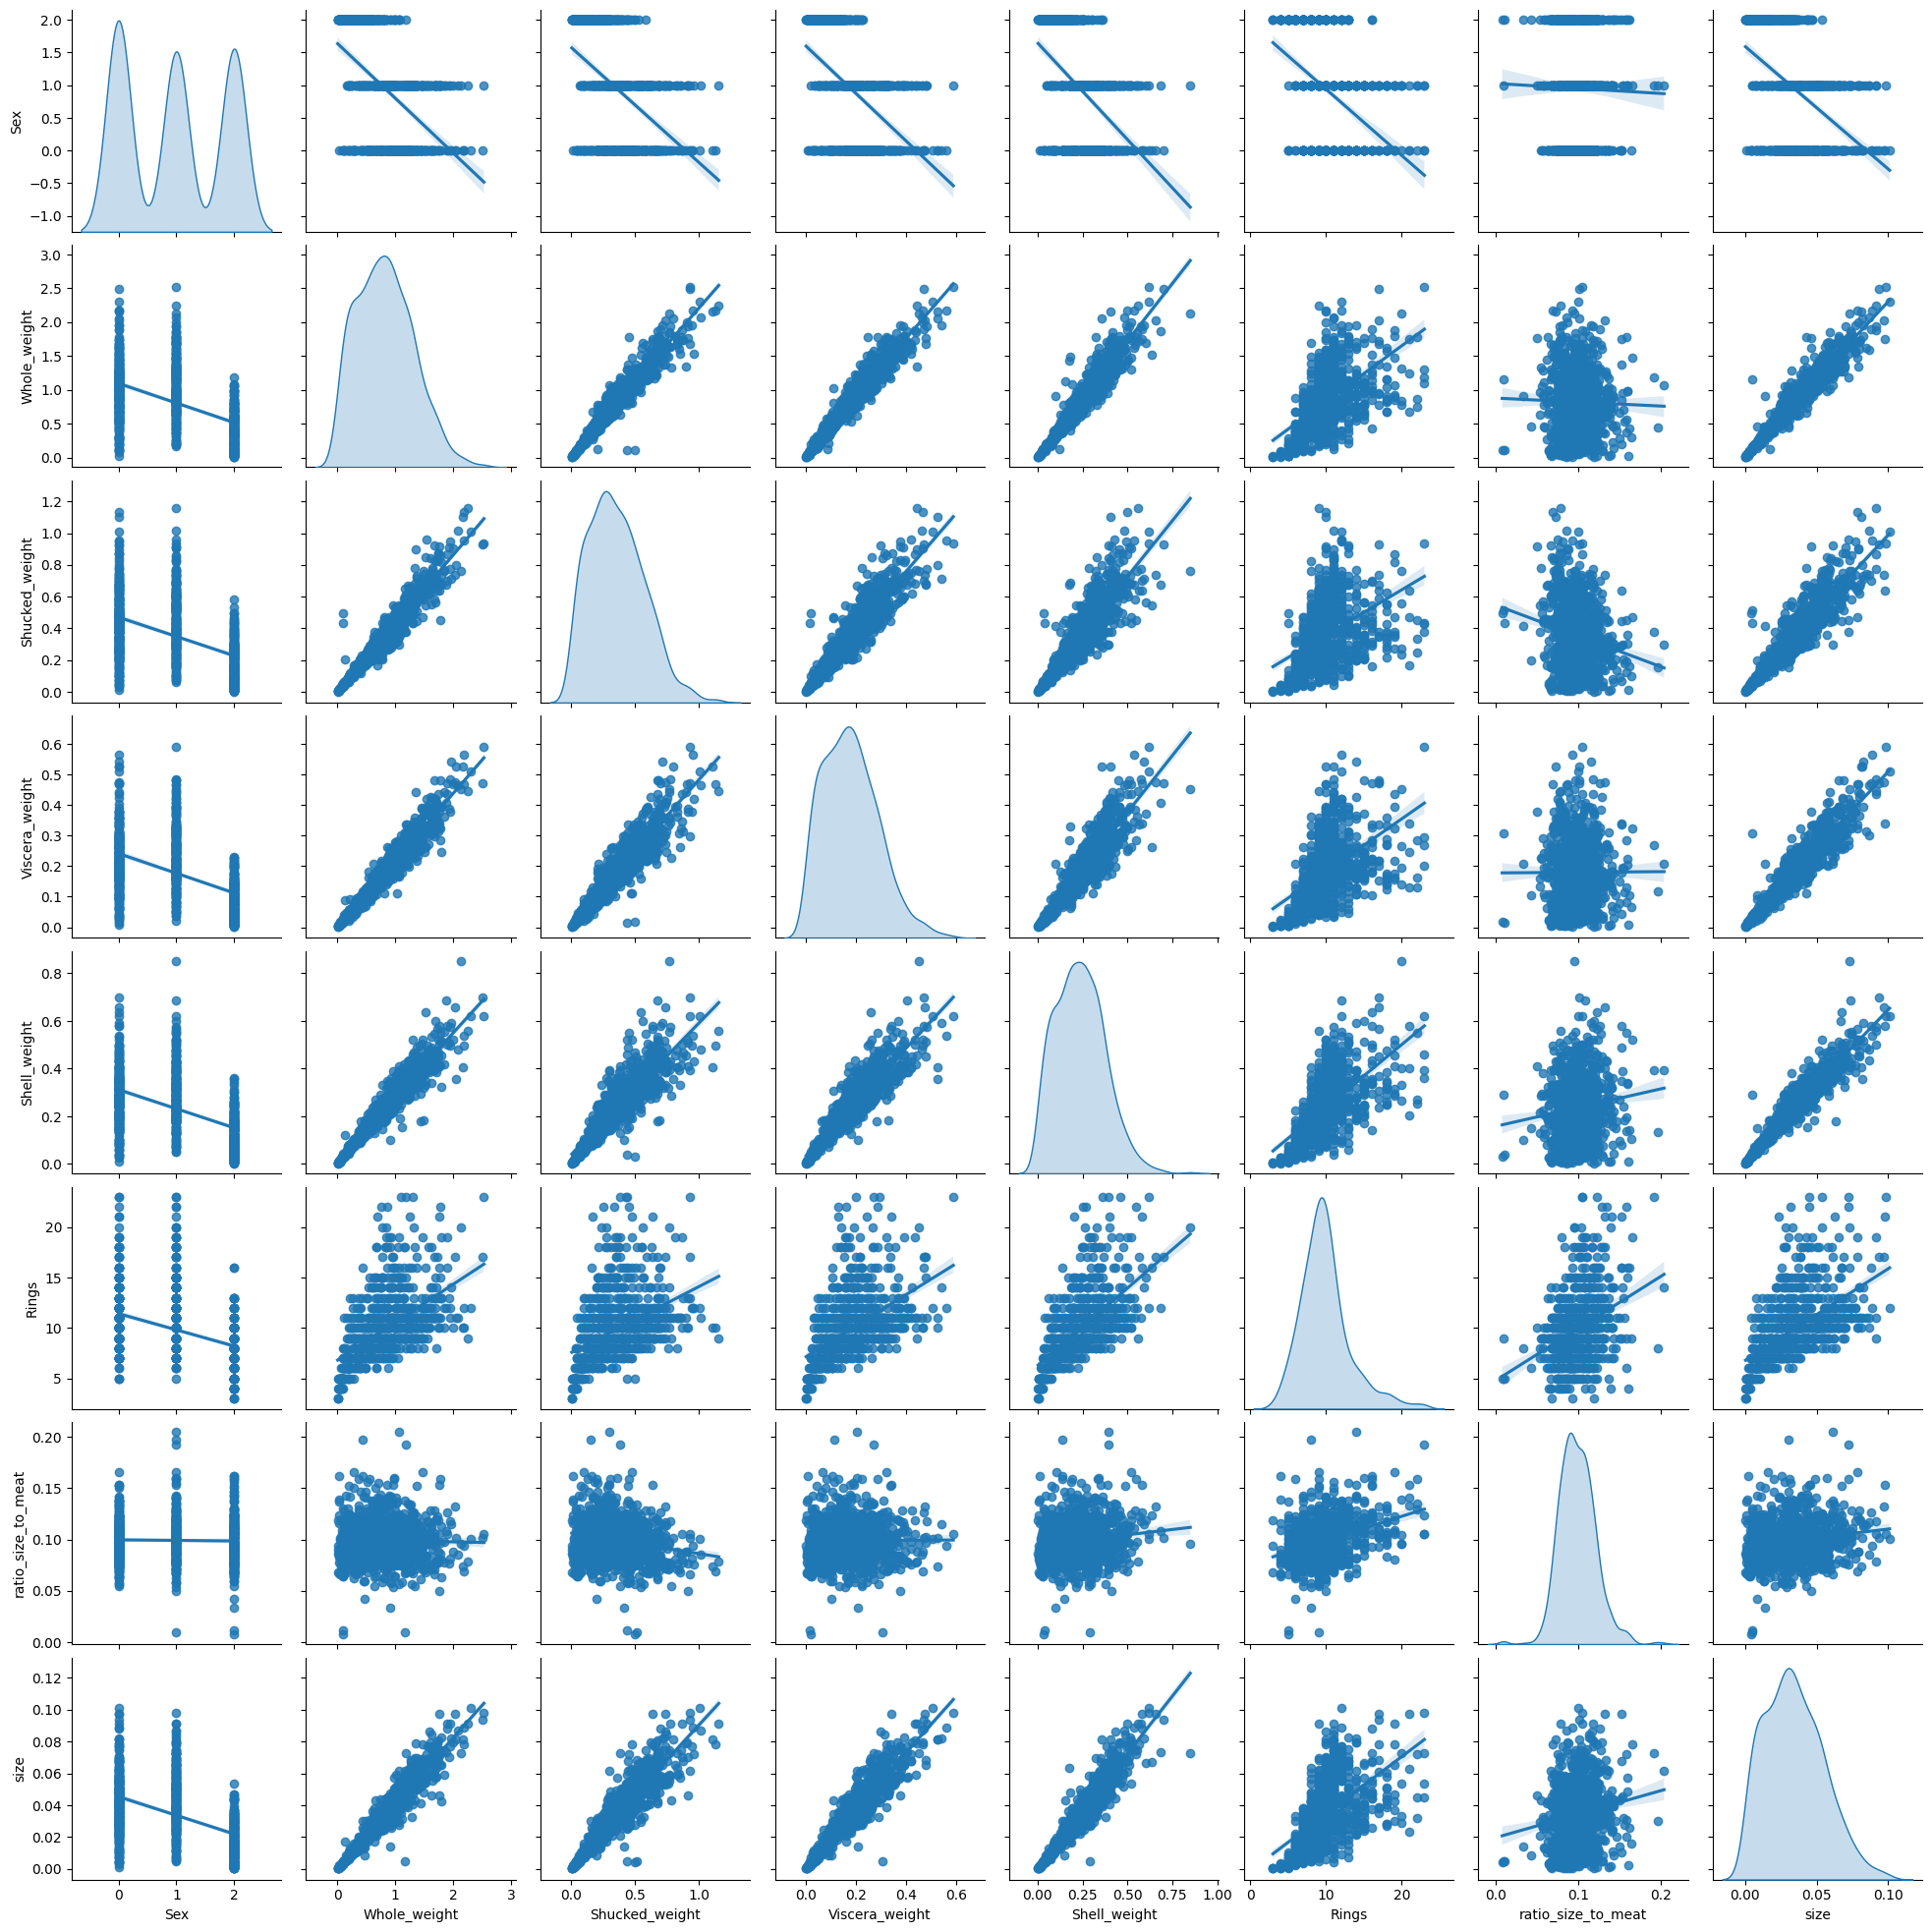

In [12]:
sns.pairplot(df.sample(frac=0.2, random_state=42), kind='reg', diag_kind='kde')

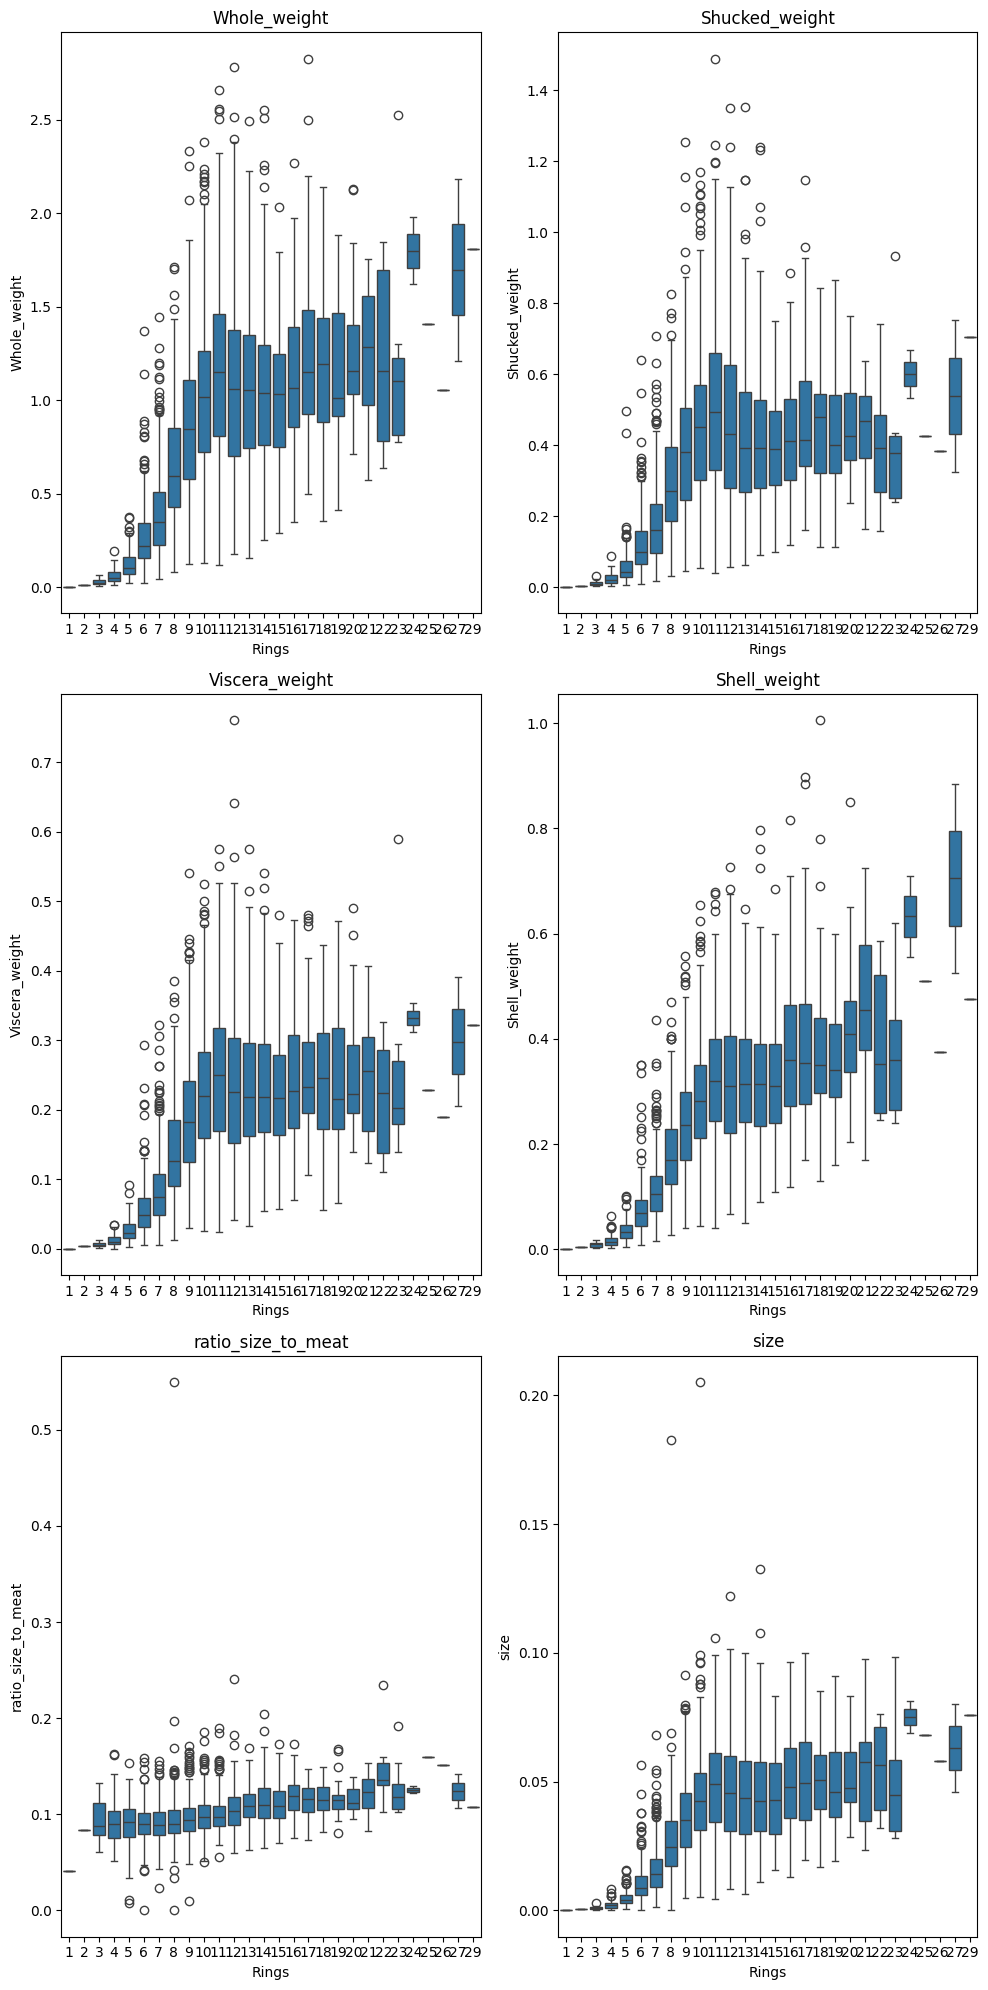

In [13]:
features_index = (df.columns.drop('Rings'))
n_features = len(features_index)
n_rows = (n_features) // 2
n_cols = 2
fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 20))

for i, feature in enumerate(features_index[1:]):
    row = i // 2
    col = i % 2
    sns.boxplot(x='Rings', y=feature, data=df, ax=axs[row][col])
    axs[row][col].set_title(feature)
    
plt.tight_layout()

plt.show()

Видно велику кількість аномалій, в середньому молюски перестають рости пілся 12-13 кілець. Спробую залишити ці стовпці, промасштабую данні

In [14]:
def make_class(rings):
    """
    Класифікація за віком молюска
    
    :param rings: кількість кілець
    :return: 0 - молодий (<=8), 1 - середній (9-11), 2 - старий (>11)
    """
    if rings <= 8:
        return 0  # Молодий
    elif rings < 12:
        return 1  # Середній
    else:
        return 2  # Старий
    
df['Age_Class'] = df['Rings'].apply(make_class)

In [15]:
# Розбиваємо дані на фічі та таргет
features = df.drop(['Rings', 'Age_Class'], axis=1)
target = df['Age_Class']

# Розбиваємо на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=.3, random_state=42)

# Масштабуємо фічі
scaler = StandardScaler()
feat_train_scaled = scaler.fit_transform(X_train)
feat_test_scaled = scaler.transform(X_test)

In [ ]:
# Створюємо модель-класифікатор
clf = KNeighborsClassifier()

# Навчаємо
clf.fit(X_train, y_train)

# Передбачаємо класи
y_pred_class = clf.predict(X_test)

Тепер перевіремо на метриках

In [17]:
print(classification_report(y_test, y_pred_class))


              precision    recall  f1-score   support

           0       0.75      0.77      0.76       437
           1       0.62      0.69      0.65       540
           2       0.64      0.47      0.54       277

    accuracy                           0.67      1254
   macro avg       0.67      0.64      0.65      1254
weighted avg       0.67      0.67      0.66      1254



**Аналіз за метриками**

Молодих модель передбачає найкраще:
* 75% відповідей є правдиві
* 77% представників знайдено

Погірше середніх:
* 62% відповідей є правдиві
* 69% представників знайдено

Найгірше старих:
* 64% відповідей є правдиві
* 47% представників знайдено

Не дивно що найгірше модель класифікує страрух, адже їх майше у 2 рази меньше аніж інших класів

Загальна точність: 67%

Усереднення дає 64-67%

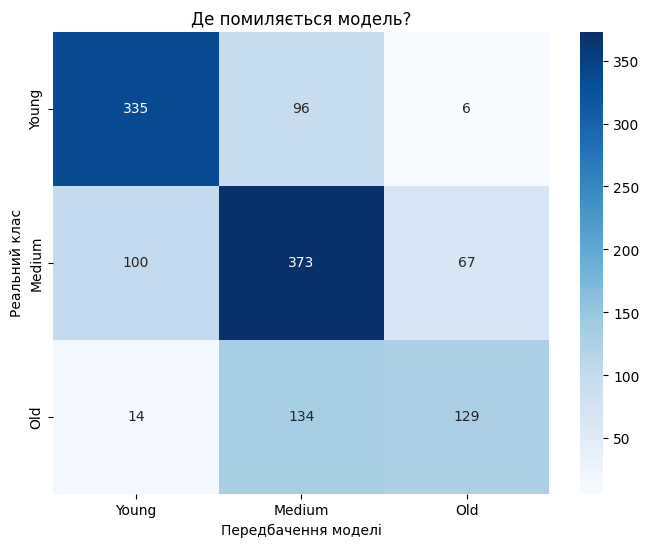

In [18]:
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Young', 'Medium', 'Old'], 
            yticklabels=['Young', 'Medium', 'Old'])
plt.xlabel('Передбачення моделі')
plt.ylabel('Реальний клас')
plt.title('Де помиляється модель?')
plt.show()